In [4]:
%pip install torchvision 1>/dev/null

import torch

Note: you may need to restart the kernel to use updated packages.


In [68]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [70]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

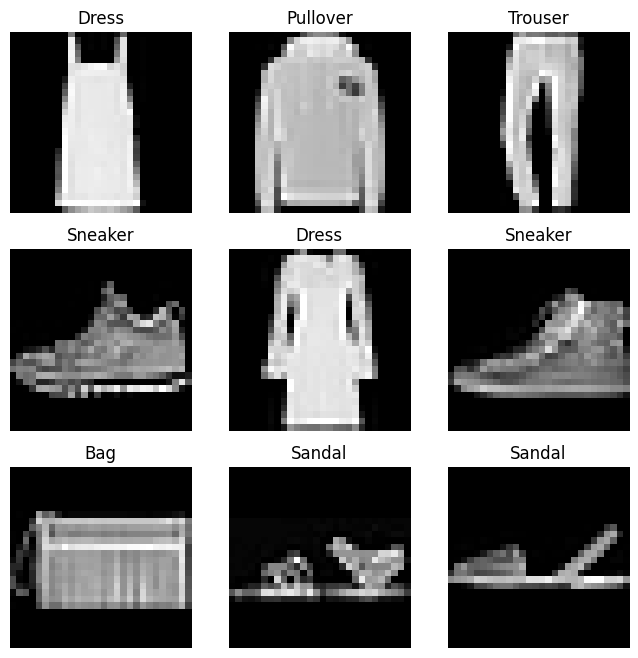

In [14]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [82]:
from torch import nn

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(784, 512),
            nn.Dropout(),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.Dropout(),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, inp):
        flat = self.flatten(inp)
        return self.sequential(flat)

model = FashionNet().to(device)

model

FashionNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (sequential): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)

## Test feedforward with random weights
Should return garbage

In [83]:
X_0, y_0 = training_data[0]
X_0 = X_0.to(device)

with torch.no_grad():
    y_0p = model(X_0)
    print(y_0p)
    

tensor([[ 0.0549, -0.0633, -0.0229, -0.2644,  0.0706,  0.0604,  0.0638,  0.0352,
         -0.0509,  0.0089]], device='cuda:0')


In [84]:
X.shape, y

(torch.Size([1, 28, 28]), 9)

# Training Time

In [85]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

loss_fn = nn.CrossEntropyLoss()

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [87]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 30
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.976743  [   64/60000]
loss: 1.012457  [ 6464/60000]
loss: 0.796001  [12864/60000]
loss: 0.942723  [19264/60000]
loss: 0.883082  [25664/60000]
loss: 0.953080  [32064/60000]
loss: 0.950375  [38464/60000]
loss: 0.942960  [44864/60000]
loss: 0.919601  [51264/60000]
loss: 0.836166  [57664/60000]
Test Error: 
 Accuracy: 68.2%, Avg loss: 0.817367 

Epoch 2
-------------------------------
loss: 0.957716  [   64/60000]
loss: 0.976973  [ 6464/60000]
loss: 0.737151  [12864/60000]
loss: 0.906452  [19264/60000]
loss: 0.840190  [25664/60000]
loss: 0.925247  [32064/60000]
loss: 0.840458  [38464/60000]
loss: 0.983200  [44864/60000]
loss: 0.994945  [51264/60000]
loss: 0.863719  [57664/60000]
Test Error: 
 Accuracy: 69.1%, Avg loss: 0.794104 

Epoch 3
-------------------------------
loss: 0.902598  [   64/60000]
loss: 0.921405  [ 6464/60000]
loss: 0.719639  [12864/60000]
loss: 0.941800  [19264/60000]
loss: 0.814666  [25664/60000]
loss: 0.829271  [32064/600